In [1]:
# Step 1 - Imports and final model

import gc
import os
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.metrics import r2_score
from tqdm import tqdm

sys.path.append(os.path.abspath("../../")) ; from EPF import variables
sys.path.append(os.path.abspath("../2_Features_build")) ; import target_features

AEMO_MAX_HORIZON = 78
HORIZON_LIST = range(1, variables.HORIZON_COUNT+1)
COMPONENT_SPECS = [
    ("base_l1", "normal", "full_range_regressor_clipped_MAE_loss", "regression"),
    ("base_l2", "arcsinh", "full_range_regressor_unclipped_RMSE_loss", "regression"),
    ("spike_probability", "spikes", "positive_spike_classifier_binary_loss", "probability"),
    ("spike_mae", "spikes", "positive_spike_regressor_unclipped_mae_loss", "regression"),
    ("spike_q90", "spikes", "positive_spike_regressor_unclipped_quantile_loss", "regression"),
    ("dip_probability", "dips", "negative_spike_classifer_unclipped_binary_loss", "probability"),
    ("dip_mae", "dips", "negative_spike_regressor_unclipped_mae_loss", "regression"),
    ("dip_q10", "dips", "negative_spike_regressor_unclipped_quantile_loss", "regression"),
]
final_params = joblib.load(variables.FINAL_PARAMS_PATH)
META_FEATURE_NAMES = final_params["stackers"][0].feature_name_
FEATURE_OBJECTIVES = list(dict.fromkeys(spec[1] for spec in COMPONENT_SPECS))

def trained_model_path(horizon, model_name):
    return variables.TRAINED_MODELS_PATH / f"h{horizon:02d}_{model_name}.joblib"

In [2]:
# Step 2 - Test data

def parquet_data_columns(path):
    schema = pq.ParquetFile(path).schema_arrow
    index_columns = {column for column in (schema.pandas_metadata or {}).get("index_columns", []) if isinstance(column, str)}
    return [column for column in schema.names if column not in index_columns]

def read_period(path, columns, start, end):
    index_col = (pq.ParquetFile(path).schema_arrow.pandas_metadata or {})["index_columns"][0]
    return pd.read_parquet(path, columns=columns, filters=[(index_col, ">", start), (index_col, "<=", end)]).sort_index().astype(np.float32)

features_optimal_amount_by_objective = {
    objective: pd.read_parquet(variables.SELECTED_FEATURES_DIR / f"FEATURES_OPTIMAL_AMOUNT_{objective}.parquet")
    for objective in FEATURE_OBJECTIVES
}

def selected_features(objective, horizon):
    selected = features_optimal_amount_by_objective[objective]
    return selected.loc[selected[f"h{horizon}"].astype(bool), "feature"].tolist()

all_selected_features = sorted({feature for objective in FEATURE_OBJECTIVES for horizon in HORIZON_LIST for feature in selected_features(objective, horizon)})
target_columns = [f"target_h{horizon}" for horizon in HORIZON_LIST]
targets_test = read_period(variables.AGG_TARGET_DATASET_PATH, target_columns, variables.TEST_START, variables.PIPELINE_END_DATE).dropna(subset=target_columns)
test_index = targets_test.index
features_test = read_period(variables.FEATURES_DATASET_PATH, all_selected_features, variables.TEST_START, variables.PIPELINE_END_DATE).reindex(test_index)

In [3]:
# Step 3 - Benchmark forecasts

observations_per_target = variables.HORIZON_GRANULARITY_IN_MINUTES // variables.FEATURE_GRANULARITY_IN_MINUTES
spot_price = pd.read_parquet(variables.TARGET_DATASET_PATH, columns=[variables.SELECTED_TARGET_COLUMN_NAME])[variables.SELECTED_TARGET_COLUMN_NAME].astype(np.float32)
naive_prediction = spot_price.rolling(observations_per_target, min_periods=observations_per_target).mean().reindex(test_index).values.astype(np.float32)

requested_aemo_columns = [f"predispatch_rrp_{variables.TARGET_REGION}_h{horizon}" for horizon in range(1, AEMO_MAX_HORIZON+1)]
available_aemo_columns = set(parquet_data_columns(variables.AEMO_PREDISPATCH_PATH))
aemo_columns = [column for column in requested_aemo_columns if column in available_aemo_columns]
aemo_test = read_period(variables.AEMO_PREDISPATCH_PATH, aemo_columns, variables.TEST_START, variables.PIPELINE_END_DATE).reindex(test_index)

def aligned_aemo_prediction(horizon):
    prediction = np.full(len(test_index), np.nan, dtype=np.float32)
    current_col = f"predispatch_rrp_{variables.TARGET_REGION}_h{horizon}"
    if horizon > AEMO_MAX_HORIZON or current_col not in aemo_test:
        return prediction

    current_price = aemo_test[current_col].values.astype(np.float32)
    offset = ((test_index.minute % 30) // variables.FEATURE_GRANULARITY_IN_MINUTES).astype(int)
    aligned = offset == 0
    prediction[aligned] = current_price[aligned]

    next_col = f"predispatch_rrp_{variables.TARGET_REGION}_h{horizon+1}"
    if (~aligned).any() and next_col in aemo_test:
        next_price = aemo_test[next_col].values.astype(np.float32)
        weight = offset.astype(np.float32) / observations_per_target
        prediction[~aligned] = (1-weight[~aligned])*current_price[~aligned] + weight[~aligned]*next_price[~aligned]

    return prediction

In [4]:
# Step 4 - Final model predictions

def predict_components(horizon):
    predictions = {}
    for objective in FEATURE_OBJECTIVES:
        model_input = target_features.append_target_time_feats(features_test[selected_features(objective, horizon)], horizon)
        for output_name, _, model_name, prediction_type in [spec for spec in COMPONENT_SPECS if spec[1] == objective]:
            model = joblib.load(trained_model_path(horizon, model_name))
            prediction = model.predict_proba(model_input)[:, 1] if prediction_type == "probability" else np.sinh(model.predict(model_input)) * variables.PRICE_TRANSFORM_SCALE
            predictions[output_name] = np.asarray(prediction, dtype=np.float32)
        del model_input, model
        gc.collect()
    return predictions

def build_meta_features(predictions):
    base_l1 = predictions["base_l1"]
    base_l2 = predictions["base_l2"]
    spike_mae = predictions["spike_mae"]
    spike_q90 = predictions["spike_q90"]
    dip_mae = predictions["dip_mae"]
    dip_q10 = predictions["dip_q10"]
    spike_probability = np.clip(predictions["spike_probability"], 1e-6, 1-1e-6)
    dip_probability = np.clip(predictions["dip_probability"], 1e-6, 1-1e-6)
    spike_mae_gap = np.maximum(spike_mae-base_l1, 0)
    spike_q90_gap = np.maximum(spike_q90-base_l1, 0)
    dip_mae_gap = np.minimum(dip_mae-base_l1, 0)
    dip_q10_gap = np.minimum(dip_q10-base_l1, 0)

    values = {
        "base_l1": base_l1,
        "base_l2": base_l2,
        "spike_mae": spike_mae,
        "spike_q90": spike_q90,
        "dip_mae": dip_mae,
        "dip_q10": dip_q10,
        "spike_probability": spike_probability,
        "dip_probability": dip_probability,
        "spike_logit": np.log(spike_probability / (1-spike_probability)),
        "dip_logit": np.log(dip_probability / (1-dip_probability)),
        "base_l2_minus_l1": base_l2-base_l1,
        "spike_mae_positive_gap": spike_mae_gap,
        "spike_q90_positive_gap": spike_q90_gap,
        "dip_mae_negative_gap": dip_mae_gap,
        "dip_q10_negative_gap": dip_q10_gap,
        "weighted_spike_mae_gap": spike_probability*spike_mae_gap,
        "weighted_spike_q90_gap": spike_probability*spike_q90_gap,
        "weighted_dip_mae_gap": dip_probability*dip_mae_gap,
        "weighted_dip_q10_gap": dip_probability*dip_q10_gap,
    }
    return np.column_stack([values[name] for name in META_FEATURE_NAMES]).astype(np.float32), base_l1

def predict_final_model(horizon):
    component_predictions = predict_components(horizon)
    meta_features, base_prediction = build_meta_features(component_predictions)
    stacker = final_params["stackers"][horizon-1]
    central_prediction = (base_prediction + stacker.predict(meta_features)).astype(np.float32)
    del component_predictions, meta_features, base_prediction, stacker
    gc.collect()
    return central_prediction

In [5]:
# Step 5 - Metrics

def precision_recall(labels, predictions):
    true_positives = np.count_nonzero(labels & predictions)
    predicted_positives = predictions.sum()
    actual_positives = labels.sum()
    precision = true_positives / predicted_positives if predicted_positives else np.nan
    recall = true_positives / actual_positives if actual_positives else np.nan
    return float(precision), float(recall)

def calculate_metrics(actual, predicted):
    valid = np.isfinite(actual) & np.isfinite(predicted)
    count = int(valid.sum())
    metric_names = ["mae", "rmse", "r2", "mbe", "wmape", "spike_mae", "dip_mae", "normal_mae", "spike_precision", "spike_recall", "spike_f2", "dip_precision", "dip_recall"]
    if not count:
        return {"n": 0, "availability_pct": 0.0, **dict.fromkeys(metric_names, np.nan)}

    actual = actual[valid].astype(float)
    predicted = predicted[valid].astype(float)
    error = predicted-actual
    absolute_error = np.abs(error)
    spikes = actual > variables.SPIKE_THRESHOLD
    dips = actual < variables.DIP_THRESHOLD
    normal = ~(spikes | dips)
    predicted_spikes = predicted > variables.SPIKE_THRESHOLD
    spike_precision, spike_recall = precision_recall(spikes, predicted_spikes)
    dip_precision, dip_recall = precision_recall(dips, predicted < variables.DIP_THRESHOLD)
    spike_f2 = 5*spike_precision*spike_recall / (4*spike_precision+spike_recall) if np.isfinite(spike_precision+spike_recall) and spike_precision+spike_recall else np.nan
    regime_mae = lambda mask: float(absolute_error[mask].mean()) if mask.any() else np.nan

    return {
        "n": count,
        "availability_pct": 100*count/len(valid),
        "mae": float(absolute_error.mean()),
        "rmse": float(np.sqrt(np.mean(error**2))),
        "r2": float(r2_score(actual, predicted)) if count >= 2 else np.nan,
        "mbe": float(error.mean()),
        "wmape": float(100*absolute_error.sum() / (np.abs(actual).sum()+1e-8)),
        "spike_mae": regime_mae(spikes),
        "dip_mae": regime_mae(dips),
        "normal_mae": regime_mae(normal),
        "spike_precision": spike_precision,
        "spike_recall": spike_recall,
        "spike_f2": spike_f2,
        "dip_precision": dip_precision,
        "dip_recall": dip_recall,
    }

def skill(reference_error, model_error):
    return 100*(reference_error-model_error)/reference_error if np.isfinite(reference_error) and reference_error else np.nan

In [6]:
# Step 6 - Evaluate and save

row_count = len(test_index)
horizon_count = len(HORIZON_LIST)
shape = (row_count, horizon_count)
predictions = {
    "actual": targets_test[target_columns].values.astype(np.float32),
    "predicted": np.full(shape, np.nan, dtype=np.float32),
    "naive": np.repeat(naive_prediction[:, None], horizon_count, axis=1),
    "aemo_predispatch": np.full(shape, np.nan, dtype=np.float32),
}

benchmark_metrics = []
benchmark_by_horizon = []

for column, horizon in enumerate(tqdm(HORIZON_LIST, desc="Evaluating horizons")):
    actual = predictions["actual"][:, column]
    central = predict_final_model(horizon)
    aemo = aligned_aemo_prediction(horizon)

    predictions["predicted"][:, column] = central
    predictions["aemo_predispatch"][:, column] = aemo

    methods = {
        "residual_stacker": central,
        "naive_persistence": naive_prediction,
        "aemo_predispatch": aemo,
    }
    metrics = {name: calculate_metrics(actual, prediction) for name, prediction in methods.items()}
    lead_hours = horizon*variables.HORIZON_GRANULARITY_IN_MINUTES/60
    benchmark_metrics.extend({"horizon": horizon, "lead_hours": lead_hours, "method": name, **values} for name, values in metrics.items())

    central_metrics = metrics["residual_stacker"]
    naive_metrics = metrics["naive_persistence"]
    aemo_metrics = metrics["aemo_predispatch"]
    common = np.isfinite(actual) & np.isfinite(aemo)

    if common.any():
        common_metrics = {
            "aemo": calculate_metrics(actual[common], aemo[common]),
            "central": calculate_metrics(actual[common], central[common]),
            "naive": calculate_metrics(actual[common], naive_prediction[common]),
        }
    else:
        common_metrics = {name: {"mae": np.nan, "rmse": np.nan} for name in ["aemo", "central", "naive"]}

    benchmark_by_horizon.append({
        "horizon": horizon,
        "lead_hours": lead_hours,
        "model_mae": central_metrics["mae"],
        "naive_mae": naive_metrics["mae"],
        "aemo_mae": aemo_metrics["mae"],
        "model_rmse": central_metrics["rmse"],
        "naive_rmse": naive_metrics["rmse"],
        "aemo_rmse": aemo_metrics["rmse"],
        "aemo_availability_pct": aemo_metrics["availability_pct"],
        "model_mae_skill_vs_naive_pct": skill(naive_metrics["mae"], central_metrics["mae"]),
        "model_rmse_skill_vs_naive_pct": skill(naive_metrics["rmse"], central_metrics["rmse"]),
        "central_spike_mae": central_metrics["spike_mae"],
        "central_spike_precision": central_metrics["spike_precision"],
        "central_spike_recall": central_metrics["spike_recall"],
        "central_spike_f2": central_metrics["spike_f2"],
        "model_mae_on_aemo_sample": common_metrics["central"]["mae"],
        "naive_mae_on_aemo_sample": common_metrics["naive"]["mae"],
        "model_mae_skill_vs_aemo_pct": skill(common_metrics["aemo"]["mae"], common_metrics["central"]["mae"]),
    })

benchmark_metrics = pd.DataFrame(benchmark_metrics)
benchmark_by_horizon = pd.DataFrame(benchmark_by_horizon)

prediction_tables = [
    pd.DataFrame(matrix, index=test_index, columns=[f"{name}_h{horizon}" for horizon in HORIZON_LIST])
    for name, matrix in predictions.items()
]
all_predictions = pd.concat(prediction_tables, axis=1)
all_predictions.index.name = "date"

variables.MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
all_predictions.to_parquet(variables.ACTUAL_VS_PREDICTED_TEST_SET)

Evaluating horizons:   0%|          | 0/96 [00:00<?, ?it/s]/home/daniel-davaris/venv_main/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Evaluating horizons:   1%|          | 1/96 [00:13<20:36, 13.02s/it]/home/daniel-davaris/venv_main/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Evaluating horizons:   2%|▏         | 2/96 [00:19<14:09,  9.03s/it]/home/daniel-davaris/venv_main/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Evaluating horizons:   3%|▎         | 3/96 [00:26<13:01,  8.40s/it]/home/daniel-davaris/venv_main/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does

,method,n,availability_pct,mae,rmse,r2,mbe,wmape,spike_mae,dip_mae,normal_mae,spike_precision,spike_recall,spike_f2,dip_precision,dip_recall
0,residual_stacker,10091520,100.0000,46.7983,376.5523,0.0547,-17.9115,43.4452,185.5641,33.2975,21.5685,0.7155,0.5570,0.5829,0.8020,0.3661
1,naive_persistence,10091520,100.0000,103.5933,534.7679,-0.9065,0.0869,96.1709,289.6362,91.2332,68.7191,0.2656,0.2657,0.2657,0.2380,0.2384
2,aemo_predispatch,7645085,75.7575,138.9327,1176.5032,-7.7103,86.4329,128.2793,613.6169,54.1854,60.8462,0.6337,0.5478,0.5630,0.7057,0.4641


,horizon,lead_hours,model_mae,naive_mae,aemo_mae,model_rmse,naive_rmse,aemo_rmse,aemo_availability_pct,model_mae_skill_vs_naive_pct,model_rmse_skill_vs_naive_pct,central_spike_mae,central_spike_precision,central_spike_recall,central_spike_f2,model_mae_on_aemo_sample,naive_mae_on_aemo_sample,model_mae_skill_vs_aemo_pct
0,1,0.5,30.5559,34.5096,51.6375,364.4038,310.6975,555.5511,94.5158,11.4569,-17.2857,149.4298,0.8825,0.8254,0.8362,31.1551,35.5185,39.6657
1,2,1.0,35.6407,49.1079,61.9364,372.5448,383.2812,660.6137,94.5158,27.4236,2.8012,163.6406,0.8354,0.7467,0.7629,35.9665,50.4086,41.9300
2,3,1.5,37.9814,59.4119,73.2658,373.5464,418.0122,758.8446,94.5158,36.0711,10.6375,167.9591,0.8149,0.7101,0.7289,37.8044,60.8883,48.4010
3,4,2.0,39.6004,68.5984,84.3896,373.8795,446.4692,873.1178,94.5158,42.2720,16.2586,170.6214,0.8048,0.6992,0.7180,39.1580,70.2036,53.5985
4,5,2.5,40.3802,76.3198,91.2650,374.3020,474.0263,921.0839,94.5158,47.0908,21.0377,172.9915,0.7981,0.6621,0.6854,40.2228,77.9982,55.9275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92,46.0,52.4965,92.5000,NaN,379.3636,541.4142,NaN,0.0000,43.2470,29.9310,201.1936,0.6769,0.4296,0.4635,NaN,NaN,NaN
92,93,46.5,51.8199,89.3730,NaN,379.0064,539.7366,NaN,0.0000,42.0184,29.7794,196.7040,0.6594,0.4693,0.4980,NaN,NaN,NaN
93,94,47.0,51.6598,86.1810,NaN,379.4881,537.9116,NaN,0.0000,40.0566,29.4516,200.2691,0.6629,0.4236,0.4565,NaN,NaN,NaN
94,95,47.5,52.0864,83.0422,NaN,379.8463,535.4438,NaN,0.0000,37.2772,29.0595,201.0813,0.6939,0.4165,0.4527,NaN,NaN,NaN


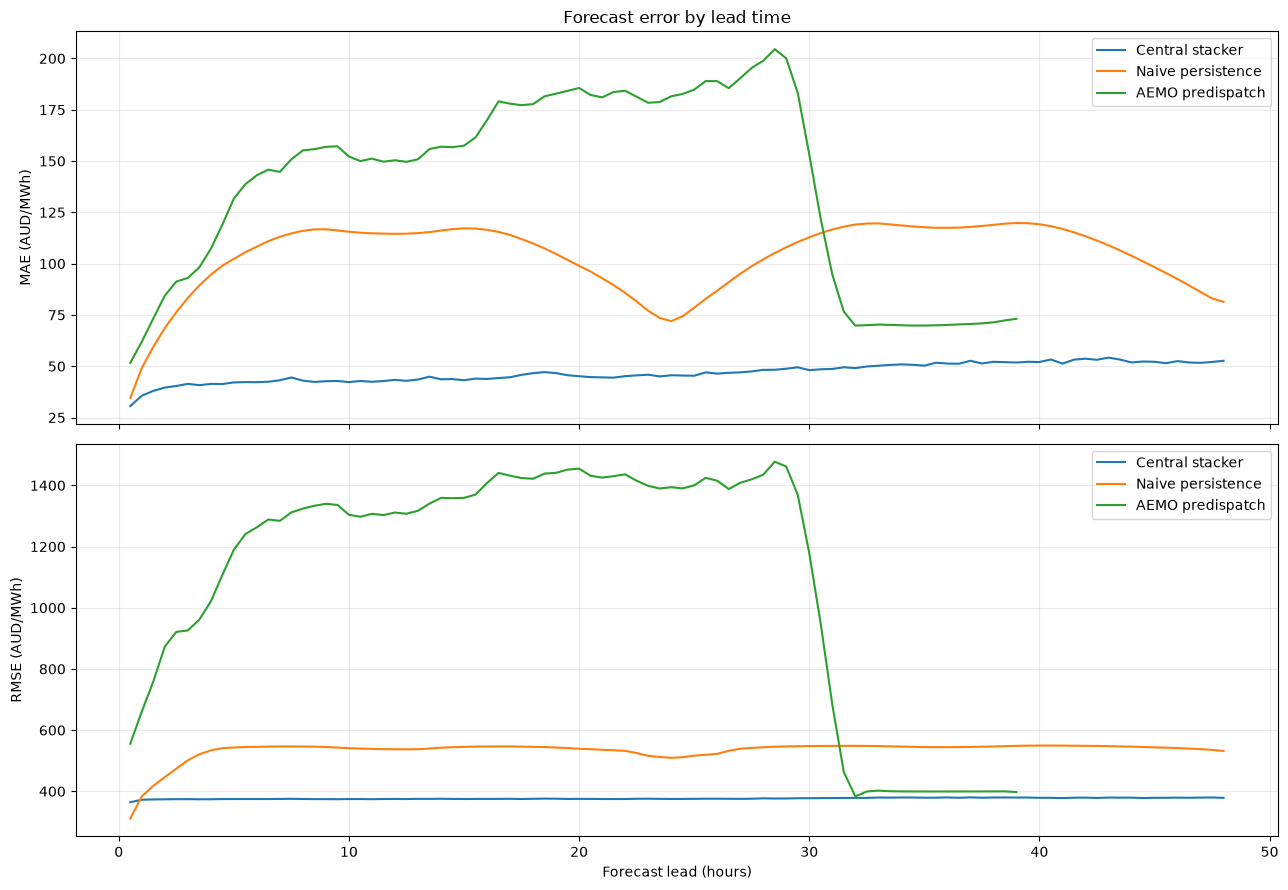

In [7]:
# Step 7 - Results

pooled_methods = {
    "residual_stacker": predictions["predicted"],
    "naive_persistence": predictions["naive"],
    "aemo_predispatch": predictions["aemo_predispatch"],
}
pooled_metrics = pd.DataFrame([
    {"method": name, **calculate_metrics(predictions["actual"].ravel(), prediction.ravel())}
    for name, prediction in pooled_methods.items()
])

display(pooled_metrics.round(4))
display(benchmark_by_horizon.round(4))

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
labels = {
    "residual_stacker": "Central stacker",
    "naive_persistence": "Naive persistence",
    "aemo_predispatch": "AEMO predispatch",
}

for method, label in labels.items():
    rows = benchmark_metrics[benchmark_metrics["method"] == method]
    axes[0].plot(rows["lead_hours"], rows["mae"], label=label)
    axes[1].plot(rows["lead_hours"], rows["rmse"], label=label)

axes[0].set(title="Forecast error by lead time", ylabel="MAE (AUD/MWh)")
axes[1].set(xlabel="Forecast lead (hours)", ylabel="RMSE (AUD/MWh)")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()